In [328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

In [122]:
df = pd.read_csv("../data/loan_dataset.csv")
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [123]:
df.shape

(32586, 13)

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB


In [125]:
df = df.drop_duplicates()

In [126]:
df.shape

(32580, 13)

In [127]:
df =df.drop("customer_id",axis =1)

In [128]:
df['Current_loan_status'] = df['Current_loan_status'].map({
    'NO DEFAULT': 0,
    'DEFAULT': 1
})

In [129]:
# Cleaning LoanAmount column by removing currency symbols and commas
df['loan_amnt'] = pd.to_numeric(
    df['loan_amnt'].astype(str).str.replace(r"[£,]", "", regex=True),
    errors='coerce'
)
#Converting customer_income and loan_amnt to numeric columns
df['customer_income'] = pd.to_numeric(df['customer_income'],errors='coerce')
df['loan_amnt'] = pd.to_numeric(df['loan_amnt'],errors='coerce')

In [130]:
df.isnull().sum()

customer_age               0
customer_income            4
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20736
cred_hist_length           0
Current_loan_status        4
dtype: int64

In [131]:
df=df.dropna(subset=['Current_loan_status'])

In [132]:
#Create 'Unknown' category for historical_default feature
df['historical_default'] = df['historical_default'].map({
    'Y': 1,
    'N': 0
}).fillna(-1)

In [133]:
#Target Distribution
df['Current_loan_status'].value_counts(normalize=True)*100

Current_loan_status
0.0    79.015226
1.0    20.984774
Name: proportion, dtype: float64

In [134]:
# Separating independent features and target variable
X = df.drop(["Current_loan_status"], axis=1)

y = df["Current_loan_status"]

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [136]:
print(X_train.shape,X_test.shape)
print(y_train.shape, y_test.shape)

(26060, 11) (6516, 11)
(26060,) (6516,)


In [137]:
X.columns

Index(['customer_age', 'customer_income', 'home_ownership',
       'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'term_years', 'historical_default',
       'cred_hist_length'],
      dtype='str')

In [138]:
num_cols = ['customer_age','customer_income','employment_duration','loan_amnt','loan_int_rate', 'term_years','cred_hist_length']

ordinal_cols = ['loan_grade']

onehot_cols = ['home_ownership','loan_intent','historical_default']

In [139]:
#Numerical feature preprocessing pipeline
num_pipeline =Pipeline(
    [
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

In [140]:
#Nominal feature preprocessing pipeline
onehot_pipeline =Pipeline(
    [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [141]:
#Ordinal feature preprocessing pipeline
ordinal_pipeline =Pipeline(
    [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OrdinalEncoder(categories=[["A","B","C","D","E"]]))
    ]
)

In [142]:
#Combine preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", onehot_pipeline, onehot_cols),
    ("ord", ordinal_pipeline, ordinal_cols)
])

In [143]:
#Final ML pipeline

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

In [144]:
#Train 
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [145]:
#Predict
y_pred = model.predict(X_test)

In [146]:
#Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      5149
         1.0       0.86      0.84      0.85      1367

    accuracy                           0.94      6516
   macro avg       0.91      0.90      0.91      6516
weighted avg       0.94      0.94      0.94      6516



In [147]:
df.isnull().sum()

customer_age              0
customer_income           4
home_ownership            0
employment_duration     895
loan_intent               0
loan_grade                0
loan_amnt                 1
loan_int_rate          3115
term_years                0
historical_default        0
cred_hist_length          0
Current_loan_status       0
dtype: int64

In [173]:
# =========================================
# MODEL B → Drop historical_default
# =========================================

# Create copy
df_model_b = df.copy()

# Drop suspicious feature
df_model_b = df_model_b.drop(
    "historical_default",
    axis=1
)


# Features & target
X_b = df_model_b.drop(
    ["Current_loan_status"],
    axis=1
)

y_b = df_model_b["Current_loan_status"]

# Train-test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

# =========================================
# Column groups
# =========================================

num_cols_b = [
    "customer_age",
    "customer_income",
    "employment_duration",
    "loan_amnt",
    "loan_int_rate",
    "cred_hist_length",
    "term_years"
]

onehot_cols_b = [
    "home_ownership",
    "loan_intent"
]

ordinal_cols_b = [
    "loan_grade"
]

# =========================================
# Preprocessor
# =========================================

preprocessor_b = ColumnTransformer([
    ("num", num_pipeline, num_cols_b),
    ("onehot", onehot_pipeline, onehot_cols_b),
    ("ordinal", ordinal_pipeline, ordinal_cols_b)
])

# =========================================
# Final model
# =========================================

model_b = Pipeline([
    ("preprocess", preprocessor_b),
    ("clf", LogisticRegression(max_iter=1000))
])

# Train
model_b.fit(X_train_b, y_train_b)

# Predict
y_pred_b = model_b.predict(X_test_b)

# Evaluation
print("MODEL B → WITHOUT historical_default\n")

print(classification_report(
    y_test_b,
    y_pred_b
))

MODEL B → WITHOUT historical_default

              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91      5149
         1.0       0.73      0.42      0.53      1367

    accuracy                           0.85      6516
   macro avg       0.80      0.69      0.72      6516
weighted avg       0.83      0.85      0.83      6516



In [171]:
df_model_b.info()

<class 'pandas.DataFrame'>
Index: 32576 entries, 0 to 32585
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_age         32576 non-null  int64  
 1   customer_income      32572 non-null  float64
 2   home_ownership       32576 non-null  str    
 3   employment_duration  31681 non-null  float64
 4   loan_intent          32576 non-null  str    
 5   loan_grade           32576 non-null  str    
 6   loan_amnt            32575 non-null  float64
 7   loan_int_rate        29461 non-null  float64
 8   term_years           32576 non-null  int64  
 9   cred_hist_length     32576 non-null  int64  
 10  Current_loan_status  32576 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 3.0 MB


In [149]:
df_model_b.columns

Index(['customer_age', 'customer_income', 'home_ownership',
       'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'term_years', 'cred_hist_length',
       'Current_loan_status'],
      dtype='str')

In [150]:
print(model_b.classes_)

[0. 1.]


In [ ]:

default_probs = model_b.predict_proba(X_test_b)[:, 1]  # probability of DEFAULT

In [152]:

fpr, tpr, roc_thresholds = roc_curve(
    y_test_b,
    default_probs
)


In [153]:
roc_auc = roc_auc_score(
    y_test_b,
    default_probs
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8414474696473758


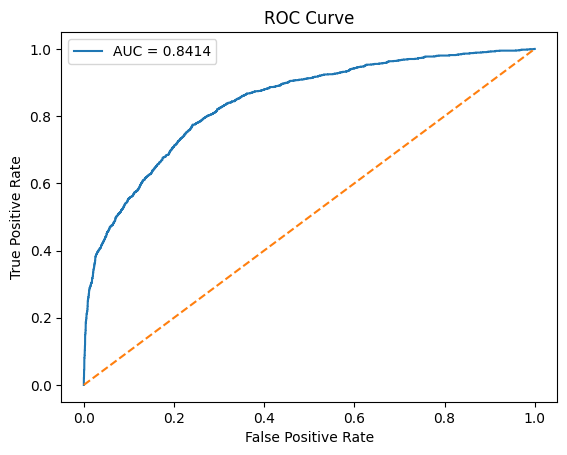

In [154]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [164]:
best_roc_index = (
    (tpr - fpr)[1:]
).argmax() + 1

best_roc_threshold = roc_thresholds[
    best_roc_index
]

print("Best ROC Threshold:",
      best_roc_threshold)

Best ROC Threshold: 0.2156753614251034


In [174]:
y_pred_roc = np.where(
    default_probs >= best_roc_threshold,
    1,
    0
)


In [175]:
print(y_pred_roc[:10])

[1 0 1 1 0 0 1 1 0 0]


In [176]:
print(y_test_b[:10])

30214    0.0
32296    0.0
21732    1.0
7560     0.0
32156    0.0
28422    0.0
31997    0.0
29376    1.0
2805     0.0
5464     0.0
Name: Current_loan_status, dtype: float64


In [177]:
print("\nClassification Report (ROC Threshold)\n")

print(classification_report(
    y_test_b,
    y_pred_roc
))


Classification Report (ROC Threshold)

              precision    recall  f1-score   support

         0.0       0.93      0.76      0.83      5149
         1.0       0.46      0.77      0.58      1367

    accuracy                           0.76      6516
   macro avg       0.69      0.77      0.71      6516
weighted avg       0.83      0.76      0.78      6516



In [180]:
for t in [0.2, 0.3, 0.5, best_roc_threshold]:
    y_pred = (default_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test_b, y_pred_roc))


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.83      5149
         1.0       0.46      0.77      0.58      1367

    accuracy                           0.76      6516
   macro avg       0.69      0.77      0.71      6516
weighted avg       0.83      0.76      0.78      6516


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.83      5149
         1.0       0.46      0.77      0.58      1367

    accuracy                           0.76      6516
   macro avg       0.69      0.77      0.71      6516
weighted avg       0.83      0.76      0.78      6516


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.83      5149
         1.0       0.46      0.77      0.58      1367

    accuracy                           0.76      6516
   macro avg       0.69      0.77      0.71      6516
weighted avg       0.83   

In [182]:
print(confusion_matrix(y_test_b,y_pred_roc))

[[3905 1244]
 [ 308 1059]]


Best F1 Threshold: 0.32681822139924355
Best F1 Score: 0.579185520312108


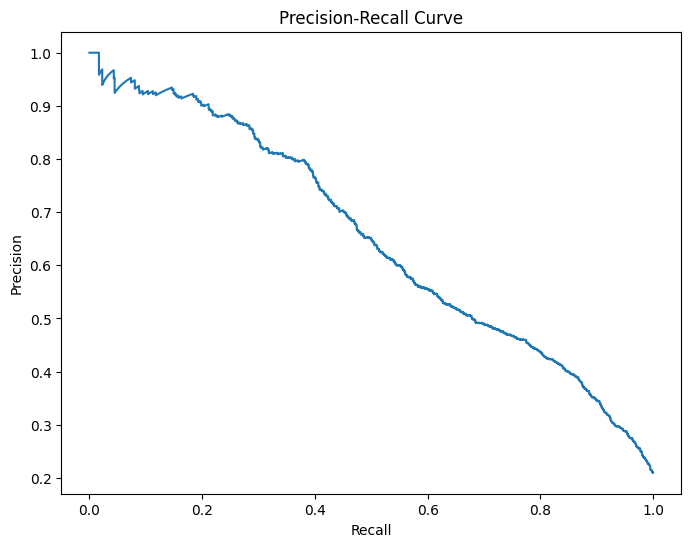


Classification Report (F1 Threshold)

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88      5149
         1.0       0.55      0.61      0.58      1367

    accuracy                           0.81      6516
   macro avg       0.72      0.74      0.73      6516
weighted avg       0.82      0.81      0.82      6516

[[4475  674]
 [ 535  832]]


In [185]:
precision, recall, pr_thresholds = (
    precision_recall_curve(
        y_test_b,
        default_probs
    )
)

f1_scores = (
    2 * precision * recall
) / (precision + recall + 1e-10)


best_f1_index = np.argmax(f1_scores)

best_f1_threshold = pr_thresholds[
    best_f1_index
]

best_f1 = f1_scores[
    best_f1_index
]

print("Best F1 Threshold:",
      best_f1_threshold)

print("Best F1 Score:",
      best_f1)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

y_pred_f1 = np.where(
    default_probs >= best_f1_threshold,
    1,
    0
)

print("\nClassification Report (F1 Threshold)\n")

print(classification_report(
    y_test_b,
    y_pred_f1
))

print(confusion_matrix(
    y_test_b,
    y_pred_f1
))

# Random Forest Baseline

In [314]:
#Random Forest Pipeline
rf_model = Pipeline([
    ("preprocess", preprocessor_b),

    ("clf", RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ))
])

In [315]:
#Train
rf_model.fit(
    X_train_b,
    y_train_b
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [316]:
#Predict
y_pred_rf = rf_model.predict(
    X_test_b
)

In [317]:
#Evaluation
print("RANDOM FOREST BASELINE\n")

print(classification_report(
    y_test_b,
    y_pred_rf
))

print(confusion_matrix(
    y_test_b,
    y_pred_rf
))

RANDOM FOREST BASELINE

              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      5149
         1.0       0.85      0.74      0.79      1367

    accuracy                           0.92      6516
   macro avg       0.89      0.85      0.87      6516
weighted avg       0.92      0.92      0.92      6516

[[4969  180]
 [ 357 1010]]


In [318]:
#Roc-Auc
rf_probs = rf_model.predict_proba(X_test_b)[:, 1]

roc_auc_rf = roc_auc_score(
    y_test_b,
    rf_probs
)

print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9308353565574696


In [319]:
#check overfitting
# Train predictions

y_train_pred_rf = rf_model.predict(
    X_train_b
)

# Test predictions

y_test_pred_rf = rf_model.predict(
    X_test_b
)

print("TRAIN PERFORMANCE\n")

print(classification_report(
    y_train_b,
    y_train_pred_rf
))

print("TEST PERFORMANCE\n")

print(classification_report(
    y_test_b,
    y_test_pred_rf
))

TRAIN PERFORMANCE

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     20591
         1.0       0.94      0.94      0.94      5469

    accuracy                           0.98     26060
   macro avg       0.96      0.96      0.96     26060
weighted avg       0.98      0.98      0.98     26060

TEST PERFORMANCE

              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      5149
         1.0       0.85      0.74      0.79      1367

    accuracy                           0.92      6516
   macro avg       0.89      0.85      0.87      6516
weighted avg       0.92      0.92      0.92      6516



In [320]:
rf_train_probs = rf_model.predict_proba(
    X_train_b
)[:, 1]

rf_test_probs = rf_model.predict_proba(
    X_test_b
)[:, 1]

train_auc = roc_auc_score(
    y_train_b,
    rf_train_probs
)

test_auc = roc_auc_score(
    y_test_b,
    rf_test_probs
)

print("Train ROC-AUC:", train_auc)

print("Test ROC-AUC:", test_auc)

Train ROC-AUC: 0.997467680649355
Test ROC-AUC: 0.9308353565574696


In [325]:
# RANDOM FOREST + SMOTE PIPELINE
# =========================================

rf_smote_model = ImbPipeline([
    
    # Preprocessing
    ("preprocess", preprocessor_b),

    # SMOTE
    ("smote", SMOTE(
        random_state=42
    )),

    # Random Forest
    ("clf", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ))
])

rf_smote_model.fit(
    X_train_b,
    y_train_b
)

y_pred_rf_smote = rf_smote_model.predict(
    X_test_b
)

print("RANDOM FOREST + SMOTE\n")

print(classification_report(
    y_test_b,
    y_pred_rf_smote
))

RANDOM FOREST + SMOTE

              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95      5149
         1.0       0.83      0.75      0.79      1367

    accuracy                           0.91      6516
   macro avg       0.88      0.86      0.87      6516
weighted avg       0.91      0.91      0.91      6516



In [326]:
rf_smote_probs = rf_smote_model.predict_proba(
    X_test_b
)[:, 1]

In [327]:
roc_auc_rf_smote = roc_auc_score(
    y_test_b,
    rf_smote_probs
)

print("ROC-AUC:", roc_auc_rf_smote)

ROC-AUC: 0.9277930260533115
